# 多层感知机（MLP）从零实现

本节不使用 `nn.Sequential` 或 `nn.Linear` 搭建模型，而是直接创建权重和偏置，手动写出前向传播。这样可以看清一个两层 MLP 从输入到预测、再从损失反向更新参数的完整过程。

## 学习目标

完成本 notebook 后，应能解释：

- Fashion-MNIST 图片为什么会被展开为 784 维向量；
- `W1、b1、W2、b2` 的形状为什么这样设计；
- ReLU 为什么让网络具备拟合非线性关系的能力；
- `loss.backward()` 和 `updater.step()` 分别做什么；
- 训练、测试集评估和具体样本预测之间有什么区别。

> **版本提示：** 本 notebook 使用教材旧版辅助 API，如 `train_ch3` 和 `predict_ch3`，需要 `d2l==0.17.6`。这些函数只负责组织训练和展示，模型本身仍是原生 PyTorch 张量运算。

## 1. 导入依赖

- `torch`：张量运算和自动微分；
- `torch.nn`：提供 `Parameter` 和交叉熵损失；
- `d2l.torch`：教材提供的数据加载、训练和可视化工具。

如果遇到 `train_ch3` 不存在，先检查当前 kernel 是否确实加载了 `d2l==0.17.6`，并在安装或切换版本后重启 kernel。

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

## 2. 加载 Fashion-MNIST

Fashion-MNIST 包含 28 × 28 的灰度服装图片，共 10 个类别。`batch_size=256` 表示训练时每次取最多 256 张图片。

迭代一次数据加载器会得到 `(X, y)`：

| 张量 | 含义 | 典型形状 |
|---|---|---|
| `X` | 一批图片 | `(256, 1, 28, 28)` |
| `y` | 每张图片的类别编号 | `(256,)` |

`train_iter` 用于学习参数；`test_iter` 只用于评估和观察预测效果，不能用来更新参数。

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

## 3. 手动创建模型参数

这个网络包含一个隐藏层：

```text
784 个输入特征 -> 256 个隐藏单元 -> 10 个类别分数
```

参数形状由矩阵乘法决定：

| 参数 | 形状 | 作用 |
|---|---:|---|
| `W1` | `(784, 256)` | 输入层到隐藏层的权重 |
| `b1` | `(256,)` | 隐藏层偏置 |
| `W2` | `(256, 10)` | 隐藏层到输出层的权重 |
| `b2` | `(10,)` | 输出层偏置 |

权重使用均值接近 0 的小随机数初始化。如果同一层所有权重都初始化为相同值，神经元会收到相同梯度，难以学习不同特征。偏置可以初始化为 0；它们只是**初始值为 0**，训练后会被优化器更新。

`nn.Parameter` 表示这些张量是需要训练的参数。`params` 列表稍后会交给 SGD 优化器。

In [4]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256
W1 = nn.Parameter(torch.randn(
num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))
params = [W1, b1, W2, b2]

## 4. 从零实现 ReLU

ReLU 对每个元素执行：

$$\operatorname{ReLU}(x)=\max(x,0)$$

负数变为 0，正数保持不变。它在两次线性变换之间加入非线性；如果没有激活函数，多层线性变换仍然可以合并成一次线性变换，增加层数也不会提升表达能力。

这里用 `torch.zeros_like(X)` 创建与输入形状、数据类型和设备一致的全零张量，再逐元素取最大值。实际项目通常直接使用 `torch.relu(X)` 或 `nn.ReLU()`。

In [5]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

## 5. 定义前向传播

网络的数学表达式是：

$$H=\operatorname{ReLU}(XW_1+b_1)$$

$$O=HW_2+b_2$$

假设当前批次有 $B$ 张图片，形状变化如下：

```text
X:          (B, 1, 28, 28)
reshape:    (B, 784)
X @ W1:     (B, 256)
H:          (B, 256)
H @ W2:     (B, 10)
输出 O:     (B, 10)
```

`-1` 让 PyTorch 根据元素总数自动推断批次维度，因此最后一个不足 256 的批次也能正常运行。`b1` 和 `b2` 会通过广播分别加到批次中的每个样本。

最终输出的是 10 个原始类别分数（logits），不是概率。`CrossEntropyLoss` 会在内部完成 softmax 相关计算，因此这里不要手动添加 softmax。

In [6]:
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1) # 这里“@”代表矩阵乘法
    return (H@W2 + b2)

## 6. 定义分类损失

交叉熵衡量模型给正确类别分配的分数是否足够高。输入是形状 `(B, 10)` 的 logits 和形状 `(B,)` 的真实类别编号。

`reduction='none'` 表示返回每个样本各自的损失，结果形状为 `(B,)`。教材训练函数会在反向传播前对它求平均，并用损失之和与样本总数计算整轮的平均损失。

In [7]:
loss = nn.CrossEntropyLoss(reduction='none')

## 7. 训练模型

`torch.optim.SGD(params, lr=lr)` 创建随机梯度下降优化器，并告诉它更新 `params` 中的 `W1、b1、W2、b2`。学习率 `lr=0.1` 决定每次沿负梯度方向移动多远。

`train_ch3` 是教材对训练循环的封装，其核心过程等价于：

```python
for X, y in train_iter:
    y_hat = net(X)              # 前向传播
    l = loss(y_hat, y)          # 计算损失
    updater.zero_grad()         # 清除上一批梯度
    l.mean().backward()         # 自动微分，计算当前梯度
    updater.step()              # 使用 SGD 更新参数
```

一个 epoch 表示完整遍历一次训练集。训练曲线中：`train loss` 应整体下降，`train acc` 和 `test acc` 应整体上升。测试准确率明显低于训练准确率时，需要警惕过拟合。

> `train_ch3` 末尾还会断言训练损失低于 0.5、训练和测试准确率高于 0.7。如果训练完成后出现 `AssertionError`，说明结果没有达到教材设定的阈值，而不一定是代码语法错误。

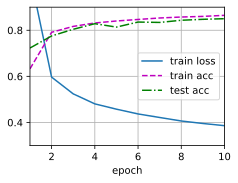

In [8]:
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

## 8. 查看一批测试样本的预测

`predict_ch3` 从 `test_iter` 取出第一批数据，使用训练后的 `net` 计算类别分数，再用 `argmax` 选出分数最高的类别并显示图片。

它用于观察具体样本，不用于训练，也不是完整的测试集评估。整个测试集的准确率已经由 `train_ch3` 中的评估步骤计算。预测阶段不会调用 `backward()` 或 `updater.step()`，因此不会改变模型参数。

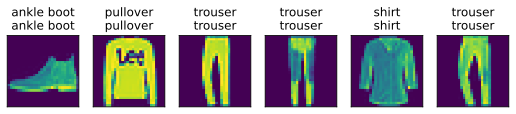

In [9]:
d2l.predict_ch3(net, test_iter)

## 9. 查看多批测试样本

教材的 `predict_ch3` 只展示第一批中的少量图片。下面的辅助函数遍历 `test_iter` 的前几批，让我们同时观察预测标签和每批准确率。

关键步骤：

1. `torch.inference_mode()` 关闭梯度记录，减少预测阶段的内存和计算开销；
2. `logits.argmax(dim=1)` 从每行的 10 个类别分数中选出预测类别；
3. `predictions == y` 逐个判断预测是否正确；
4. 每批只显示前 `num_images` 张，但准确率使用当前批次的全部样本计算。

> 当前 `net` 是普通 Python 函数，没有 `eval()` 方法；如果以后改写为 `nn.Module`，函数会调用 `net.eval()`，使 Dropout、BatchNorm 等层切换到评估模式。

In [10]:
def show_test_batches(net, test_iter, num_batches=3, num_images=10):
    # net 是函数时没有 eval()；nn.Module 模型才调用 eval()
    if isinstance(net, torch.nn.Module):
        net.eval()

    with torch.inference_mode():
        for batch_index, (X, y) in enumerate(test_iter):
            if batch_index >= num_batches:
                break

            # 使用训练好的模型预测
            logits = net(X)
            predictions = logits.argmax(dim=1)

            # 只显示当前批次的前 num_images 张
            count = min(num_images, X.shape[0])
            images = X[:count].reshape((-1, 28, 28))

            true_labels = d2l.get_fashion_mnist_labels(
                y[:count]
            )
            predicted_labels = d2l.get_fashion_mnist_labels(
                predictions[:count]
            )

            titles = [
                f"{true_label} → {predicted_label}"
                for true_label, predicted_label
                in zip(true_labels, predicted_labels)
            ]

            d2l.show_images(
                images,
                1,
                count,
                titles=titles
            )

            batch_accuracy = (
                predictions == y
            ).float().mean().item()

            print(
                f"第 {batch_index + 1} 批："
                f"准确率 {batch_accuracy:.2%}"
            )

### 执行多批预测

这里读取前 3 批，每批展示前 10 张图片。图片标题采用“真实类别 → 预测类别”的形式；左右不同即表示预测错误。

各批准确率存在波动是正常现象，因为它们只反映各自包含的有限样本。评价模型整体效果时，应以完整测试集准确率为准。若希望观察更多数据，可以调整 `num_batches` 和 `num_images`，但一次显示太多图片会降低可读性。

第 1 批：准确率 88.28%
第 2 批：准确率 85.16%
第 3 批：准确率 84.38%


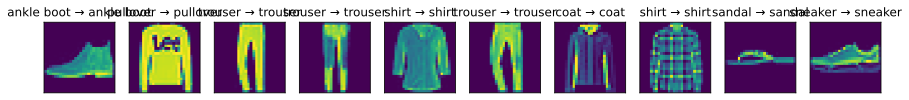

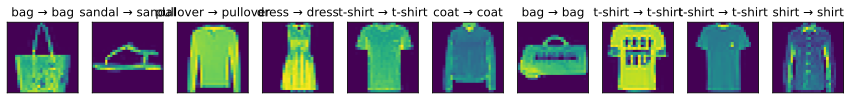

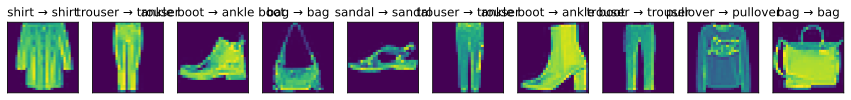

In [11]:
show_test_batches(
    net,
    test_iter,
    num_batches=3,
    num_images=10
)

## 10. 复习清单

### 完整数据流

```text
图片 X
  -> 展平为 784 维
  -> X @ W1 + b1
  -> ReLU 得到隐藏表示 H
  -> H @ W2 + b2
  -> 得到 10 个 logits
  -> 交叉熵比较 logits 与真实标签 y
  -> backward 计算梯度
  -> SGD 更新 W1、b1、W2、b2
```

### 应能回答的问题

- 为什么 `W1` 是 `(784, 256)`，而 `W2` 是 `(256, 10)`？
- 为什么权重随机初始化，而偏置可以初始化为 0？
- 为什么模型最后不需要显式调用 softmax？
- `zero_grad()`、`backward()`、`step()` 的执行顺序为什么不能颠倒？
- 为什么预测时使用 `inference_mode()`，却不能在训练时使用？

### 小练习

1. 在前向传播中打印每一步的形状，验证上面的形状推导。
2. 把隐藏单元数从 256 改成 64，观察训练速度和准确率变化。注意同时重新执行参数初始化及其后的所有单元。
3. 将学习率分别改为 0.01 和 1.0，比较损失曲线，解释步长过小或过大的表现。
4. 从多批预测结果中记录常见误判类别，例如 `shirt` 与 `t-shirt`，思考仅使用全连接层为什么难以区分它们。